### About this assignment
This assignment is devoted to solving regression problem on taxi ride dataset, with features analysis and finding good features for prediction. Also here we meet with the libraries `seaborn` and `sklearn`.

In the assignment we will use `folium` library. Install it if necessary.

In [1]:
# !pip install folium

In [3]:
import folium

m = folium.Map(location=(53.0833684, 8.8137641), zoom_start=12)

m

If everything is OK then you should see a map of Bremen.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set(style="darkgrid")

np.random.seed(0)

## Part 0. Data preparation (1 pts)

**Task 1 (1 pts)**. We are going to work with data from the competition [New York City Taxi Trip Duration](https://www.kaggle.com/c/nyc-taxi-trip-duration/overview), where one should predict taxi ride duration time. Download the training set from this competition and load it:

In [11]:
#Your code here

train_df = pd.read_csv("train.csv")
print(train_df.shape)
# train_df.head()

(1458644, 11)


Pay attention to the columns `pickup_datetime` and `dropoff_datetime`. `dropoff_datetime` was added by organizers only to the training set. So this column can't be used for prediction, let's delete it. In `pickup_datetime` you can find date and time of ride start. For convenience let's transform these dates to `datetime`-objects

In [12]:
#Your code here
train_df = train_df.drop(columns=['dropoff_datetime'])
train_df['pickup_datetime'] = pd.to_datetime(train_df['pickup_datetime'])
train_df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In the column `trip_duration` you can find target values for prediction. Let's look at target distribution on the training set. Plot the histogram for this:

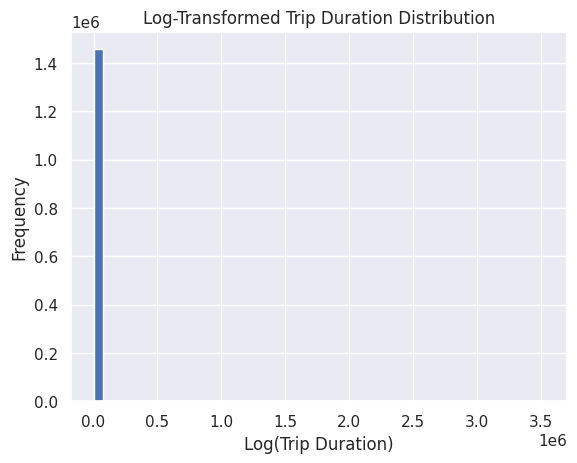

In [ ]:
#Your code here
plt.figure()
plt.hist((train_df["trip_duration"]), bins=50)
plt.xlabel("Trip Duration")
plt.ylabel("Frequency")
plt.title("Trip Duration Distribution")
plt.show()

**Question**: What can be said about target variable based on this histogram?

**Answers Here**

Since most of the rides are short the distribution is rightly skewed.

The target is not normally distributed where trip duration is highly asymmetric and has extreme outliers 

In the competition RMSLE is used as a quality metric:
$$\text{RMSLE}(X, y, a) = \sqrt{\frac{1}{N}\sum_{i=1}^{N} \big(\log{(y_i + 1)} - \log{(a(x_i) + 1)}\big)^2}$$

**Question**: How do you think, why the organizers used RMSLE and not RMSE?

**Your answer here**: RMSLE reduces the influence of very large targets and treats proportional errors similarly across scales. So in this case RMSLE focuses on relative error so short trips and long trips are compared more sensibly and it reduces the influence of outliers.

Standard linear regression model in `sklearn` is usually trained by minimizing MSE and not RMSLE. Let's use the following trick: we will predict not the original target, but its logarithm $\hat{y}_i = \log{(y_i + 1)}$. Then the prediction of the original target can be found by $a(x_i) = \exp(\hat{a}(x_i)) - 1$, where $\hat{a}(x_i)$ is prediction from the model that is trained on the modified target $\hat{y}_i$.

So we transform the RMSLE optimization problem to standard MSE optimization. Moreover, taking the logarithm gives us additional useful property. To see it let's add to the training set the column  `log_trip_duration` (use the function `np.log1p`) and plot the histogram of modified target. Delete the column with the old target.

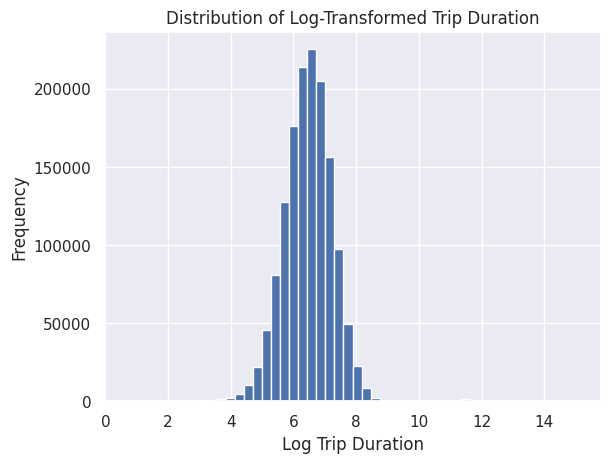

In [19]:
#Your code here
train_df["log_trip_duration"] = np.log1p(train_df["trip_duration"])

plt.figure()
plt.hist(train_df["log_trip_duration"], bins=50)
plt.xlabel("Log Trip Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed Trip Duration")
plt.show()

In order to start with something, let's compute the metric value for constant prediction:

In [21]:
def rmsle(log1p_y_true, log1p_y_pred): 
    return np.sqrt(np.mean((log1p_y_true - log1p_y_pred) ** 2))

y_log = train_df["log_trip_duration"].values
best_const = np.mean(y_log)
y_pred_const = np.full_like(y_log, best_const)

rmsle_best_const = rmsle(y_log, y_pred_const)
print(rmsle_best_const)
assert np.allclose(rmsle_best_const, 0.79575, 1e-4)

0.7957592365411507


## Part 1. Analyzing `pickup_datetime` (2 pts)

**Task 2 (0.25 pts)**. Let's look at a distribution of number of rides for each day of the year. Plot the dependence between number of rides and day number in a year (for example, you may use `sns.countplot`):

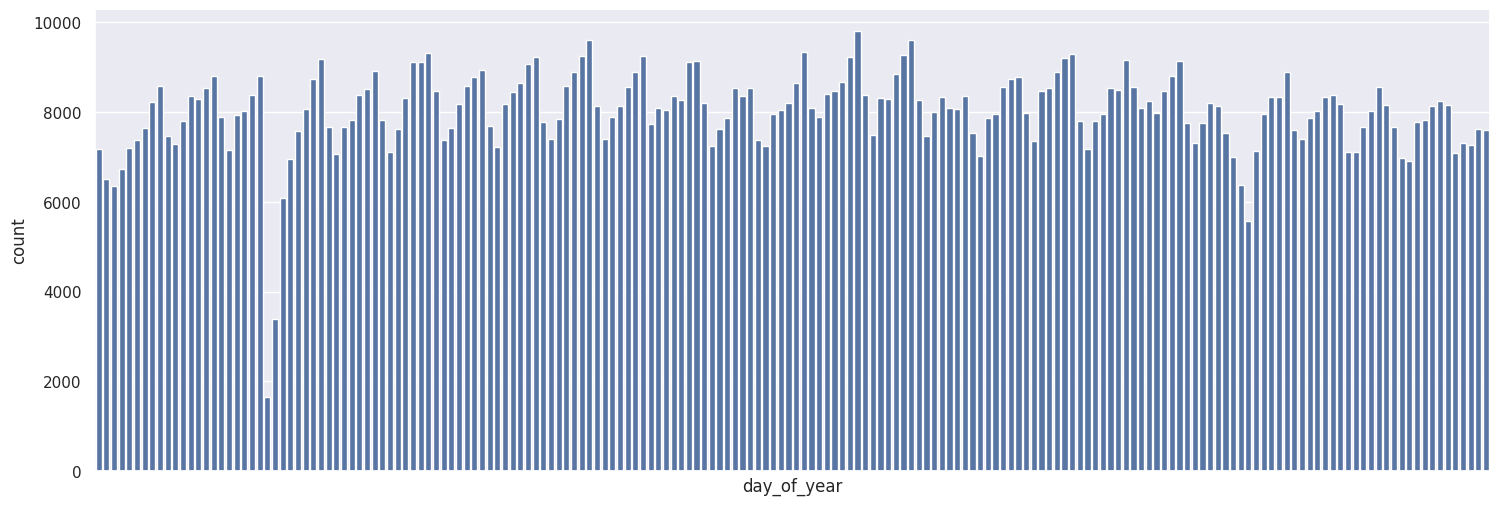

In [44]:
#Your code here
train_df["day_of_year"] = train_df["pickup_datetime"].dt.dayofyear
rides_per_day = train_df.groupby("day_of_year").size()

plt.figure(figsize=(18, 6))
sns.countplot(x=train_df["day_of_year"])
plt.xticks([])
plt.show()

**Question**: As you probably noted on the plot there are 2 periods with too small number of rides. Find out what happened in New York City in the corresponding dates.

**Your answer here**: One of the most notable dips in taxi ride counts in 2016 was caused by Winter Storm Jonas, a major blizzard that impacted NYC and much of the Eastern United States.

Plot number of rides w.r.t. day of a week and hours of a day (use `sns.relplot`):

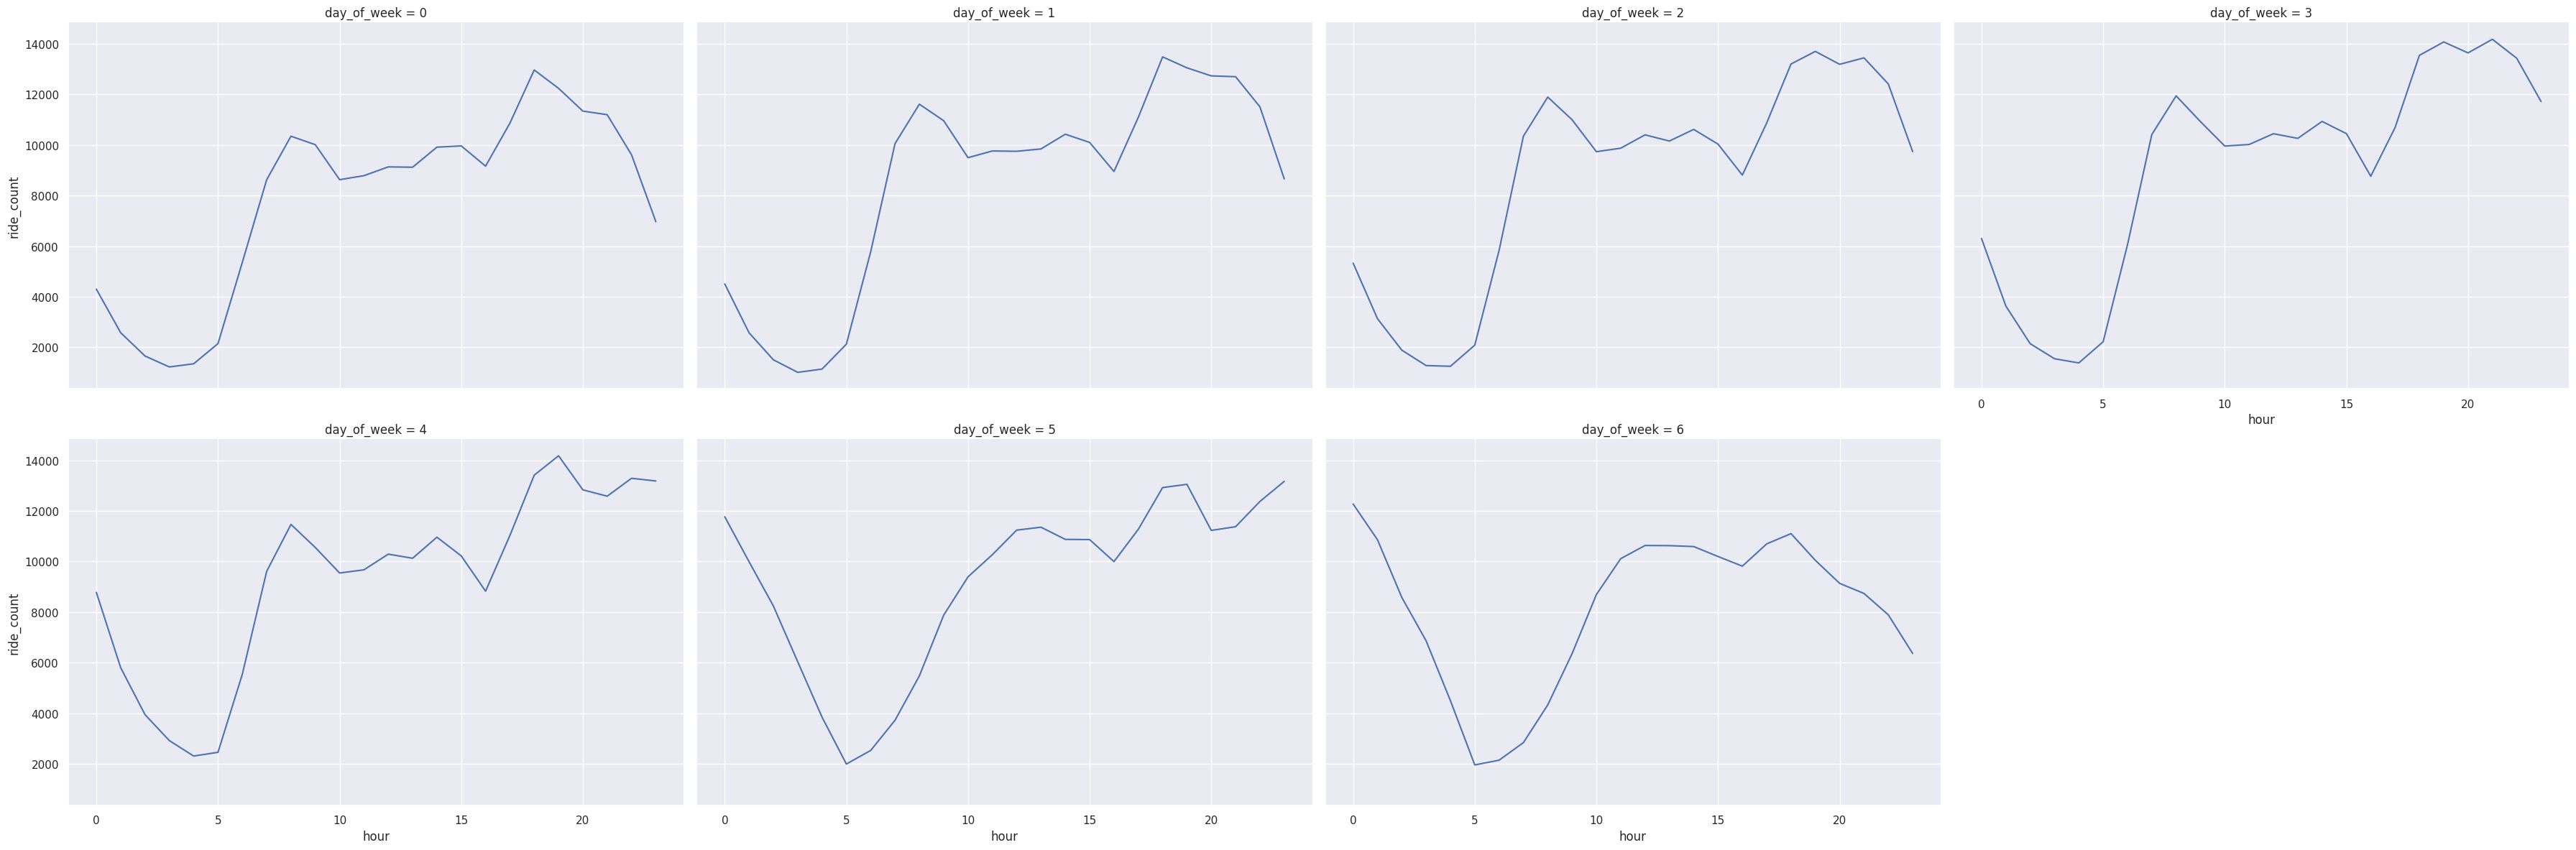

In [45]:
#Your code here
train_df["day_of_week"] = train_df["pickup_datetime"].dt.dayofweek
train_df["hour"] = train_df["pickup_datetime"].dt.hour
rides_by_time = (
    train_df
    .groupby(["day_of_week", "hour"])
    .size()
    .reset_index(name="ride_count")
)

sns.relplot(
    data=rides_by_time,
    x="hour",
    y="ride_count",
    col="day_of_week",
    kind="line",
    col_wrap=4,
    height=6,
    aspect=1.5
)

**Task 3 (0.5 pts)**. Plot number of rides w.r.t. hours of a day for different months (different curves corresponding to different months should be given in different colors; use `hue` in `sns.relplot`). In analogous way plot number of rides w.r.t. hours of a day for different days in a week.

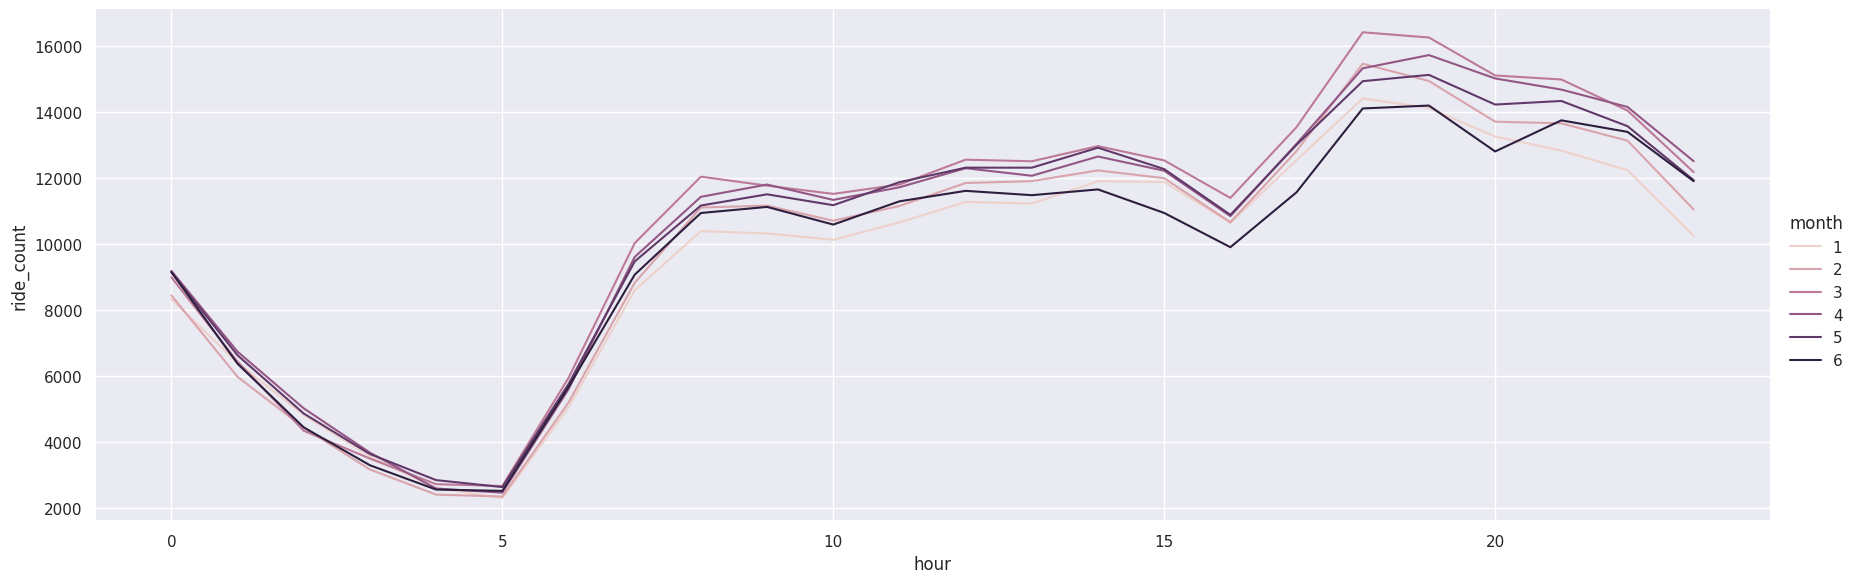

In [46]:
#Your code here
train_df["month"] = train_df["pickup_datetime"].dt.month
train_df["hour"] = train_df["pickup_datetime"].dt.hour

rides_by_month_hour = (
    train_df
    .groupby(["month", "hour"])
    .size()
    .reset_index(name="ride_count")
)

sns.relplot(
    data=rides_by_month_hour,
    x="hour",
    y="ride_count",
    hue="month",
    kind="line",
    height=6,
    aspect=3
)

**Question**: What conclusions can be made based on the constructed plots? Are some days of a week differ somehow from the others? And what about hours of a day? What are the reasons for it?

**Your answer here**:

We can say that Monday-Friday we see a lot more rides during midday in contrast with the weekend, i suspect this is because people are busier during those days and they hitch more taxi rides to go work and etc. But on weekends we see more taxi rides later at night because people go out more. In the morning at 5AM at all days we see a drastic decrease in rides.



**Task 4 (0.5 pts)**. Split dataset into train and test part in a ratio 7:3 (use `train_test_split` from `sklearn`). Using the train part plot the dependence between mean logarithm of ride duration w.r.t. day of a week. Then do the same for hour of a day and day number of a year.

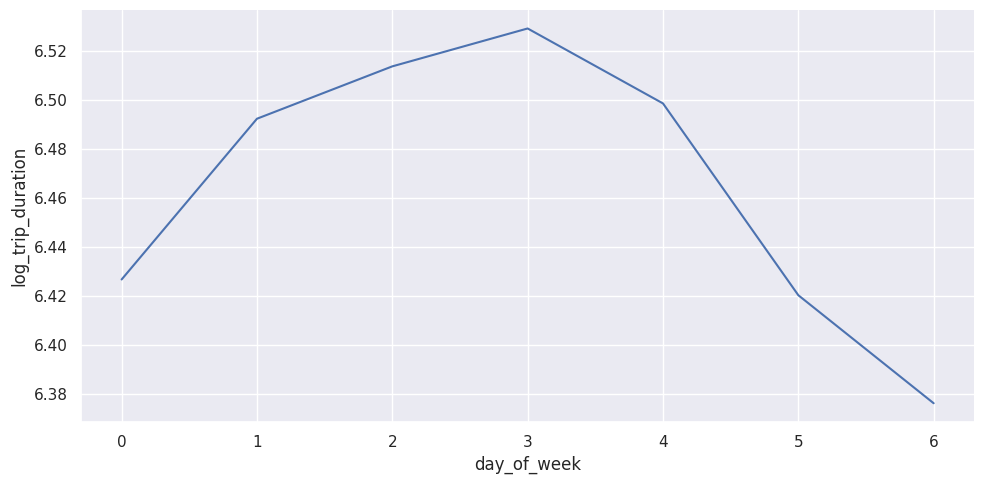

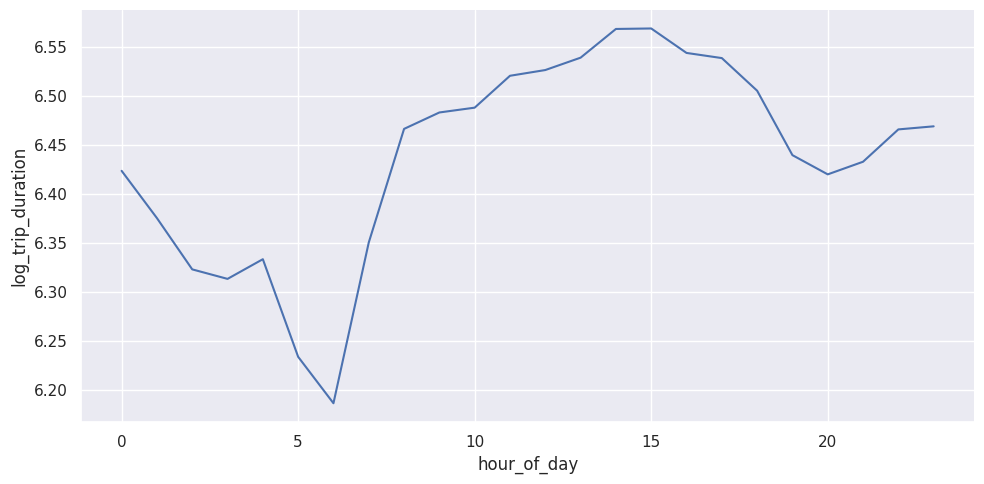

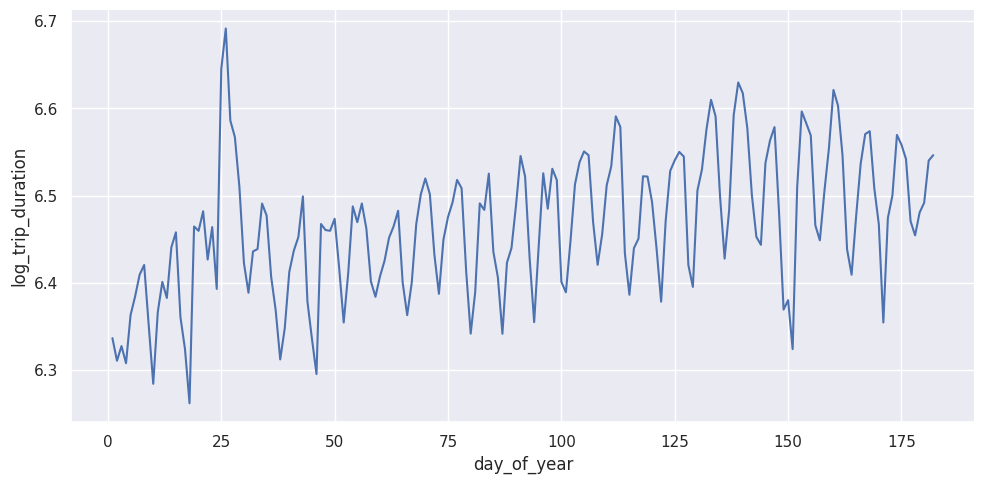

In [59]:
#Your code here
from sklearn.model_selection import train_test_split

X = train_df.drop(columns="log_trip_duration")
y = train_df["log_trip_duration"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

train_part = X_train.copy()
train_part["log_trip_duration"] = y_train

train_part["day_of_week"] = train_part["pickup_datetime"].dt.dayofweek
train_part["hour_of_day"] = train_part["pickup_datetime"].dt.hour
train_part["day_of_year"] = train_part["pickup_datetime"].dt.dayofyear

mean_by_weekday = (
    train_part
    .groupby("day_of_week")["log_trip_duration"]
    .mean()
    .reset_index()
)

mean_by_hour = (
    train_part
    .groupby("hour_of_day")["log_trip_duration"]
    .mean()
    .reset_index()
)

mean_by_yearday = (
    train_part
    .groupby("day_of_year")["log_trip_duration"]
    .mean()
    .reset_index()
)

sns.relplot(
    data=mean_by_weekday,
    x="day_of_week",
    y="log_trip_duration",
    kind="line",
    height=5,
    aspect=2
)

sns.relplot(
    data=mean_by_hour,
    x="hour_of_day",
    y="log_trip_duration",
    kind="line",
    height=5,
    aspect=2
)

sns.relplot(
    data=mean_by_yearday,
    x="day_of_year",
    y="log_trip_duration",
    kind="line",
    height=5,
    aspect=2
)

**Question**: Are the plots of target variable w.r.t. day of a week and hour of a day similar to the analogous plots for number of rides? Why? What is happening to the mean target in those two anomalous periods? Why is that happening? Do you see any trend on a plot of dependence between `log_trip_duration` and day number of a year?

**Your answer here**: No they are not similar since the number of rides measures demand and the mean log_trip_duration measures average trip length. There are a few factors that go into this like rush hour, weekend, blizzard, late night.
In the two anomalous periods mean duration increases during those periods since there are fewer rides but longer in average duration.

Add the following features to the dataset based on `pickup_datetime`:
1. Day of a week
2. Month
3. Hour
4. Is the period anomalous (two binary features corresponding to two anomalous periods)
5. Day number in a year

In [ ]:
#Your code here
train_df["day_of_week"] = train_df["pickup_datetime"].dt.dayofweek
train_df["month"] = train_df["pickup_datetime"].dt.month
train_df["hour"] = train_df["pickup_datetime"].dt.hour
train_df["day_of_year"] = train_df["pickup_datetime"].dt.dayofyear

anomaly1_start, anomaly1_end = 23, 24
anomaly2_start, anomaly2_end = 210, 212

train_df["anomaly_1"] = (
    (train_df["day_of_year"] >= anomaly1_start) &
    (train_df["day_of_year"] <= anomaly1_end)
).astype(int)

train_df["anomaly_2"] = (
    (train_df["day_of_year"] >= anomaly2_start) &
    (train_df["day_of_year"] <= anomaly2_end)
).astype(int)

So, we have created a set of features.

**Question**: Which of the features _should be considered in this task_ as cathegorical, and which - as numerical? Why?

**Your answer here**: 
day_of_week - categorical
month - categorical
hour - categorical
anomaly1, anomaly2 - categorical (binary)
day_of_year = numerical

**Task 5 (0.75 pts)**. Fit `Ridge`-regression with default parameters, encoding all cathegorical features using `OneHotEncoder`. Numerical features should be normalized using `StandardScaler`. Use only features that were created in this part of the assignment.

In [ ]:
#Your code here
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

categorical_features = [
    "day_of_week",
    "month",
    "hour",
    "anomaly_1",
    "anomaly_2"
]

numerical_features = ["day_of_year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("ridge", Ridge())
    ]
)

model.fit(X_train, y_train)

                id  vendor_id     pickup_datetime  passenger_count  \
0        id2875421          2 2016-03-14 17:24:55                1   
1        id2377394          1 2016-06-12 00:43:35                1   
2        id3858529          2 2016-01-19 11:35:24                1   
3        id3504673          2 2016-04-06 19:32:31                1   
4        id2181028          2 2016-03-26 13:30:55                1   
...            ...        ...                 ...              ...   
1458639  id2376096          2 2016-04-08 13:31:04                4   
1458640  id1049543          1 2016-01-10 07:35:15                1   
1458641  id2304944          2 2016-04-22 06:57:41                1   
1458642  id2714485          1 2016-01-05 15:56:26                1   
1458643  id1209952          1 2016-04-05 14:44:25                1   

         pickup_longitude  pickup_latitude  dropoff_longitude  \
0              -73.982155        40.767937         -73.964630   
1              -73.980415    

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

## Part 2. Analyzing coordinates (3 pts)
To the current moment we have already dived into the data about pickup start date and time. Now let's look at the information about geographical coordinates of trip start and finish. Here you can find a function that plots points of trip start and finish on a real map. Examples for its usage you may find below. Please pay attention that only a small portion of data should be given to this function. Otherwise everything would work very slowly.

In [72]:
import folium

def show_circles_on_map(data, latitude_column, longitude_column, color):
    """
    The function draws map with circles on it.
    The center of the map is the mean of coordinates passed in data.
    
    data: DataFrame that contains columns latitude_column and longitude_column
    latitude_column: string, the name of column for latitude coordinates
    longitude_column: string, the name of column for longitude coordinates
    color: string, the color of circles to be drawn
    """

    location = (data[latitude_column].mean(), data[longitude_column].mean())
    m = folium.Map(location=location)

    for _, row in data.iterrows():
        folium.Circle(
            radius=100,
            location=(row[latitude_column], row[longitude_column]),
            color=color,
            fill_color=color,
            fill=True
        ).add_to(m)

    return m

In [ ]:
show_circles_on_map(train_df.sample(1000), "pickup_latitude", "pickup_longitude", "blue")

In [74]:
show_circles_on_map(train_df.sample(1000), "dropoff_latitude", "dropoff_longitude", "blue")

**Question**: Which points (or point clusters) are differ from others on this map and can be useful for our problem? What are their peculiarities? Why have you chosen them?

**Your answer here**: Most of the point clusters are located in Manhattan New York which is considered as the center of NY and can improve prediction. We can see a lot of clusters from two different airports aswell which are also predictable, and there are a lot of clusters scattered around NY neighbourhoods aswell. There are few outliers in the map also.

**Task 6 (0.75 pts)**. Ride time can be computed as a ratio of covered distance to mean speed $t = s / v_{\text{mean}}$. Hence it is quite obvious that one of the most informative feature here for target prediction would be the covered distance. We can't compute the exact covered distance for taxi ride but we can approximate it using distance between start and finish coordinate points. Here we may use `haversine` function. Compute the approximate distance for all taxi rides and add this information to the column `haversine`.

In [ ]:
#Your code here
import numpy as np

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    
    # Convert degrees to radians
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    # Differences
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Haversine formula
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

train_df["haversine"] = haversine_distance(
    train_df["pickup_latitude"],
    train_df["pickup_longitude"],
    train_df["dropoff_latitude"],
    train_df["dropoff_longitude"]
)

# print(train_df.head())

          id  vendor_id     pickup_datetime  passenger_count  \
0  id2875421          2 2016-03-14 17:24:55                1   
1  id2377394          1 2016-06-12 00:43:35                1   
2  id3858529          2 2016-01-19 11:35:24                1   
3  id3504673          2 2016-04-06 19:32:31                1   
4  id2181028          2 2016-03-26 13:30:55                1   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.982155        40.767937         -73.964630         40.765602   
1        -73.980415        40.738564         -73.999481         40.731152   
2        -73.979027        40.763939         -74.005333         40.710087   
3        -74.010040        40.719971         -74.012268         40.706718   
4        -73.973053        40.793209         -73.972923         40.782520   

  store_and_fwd_flag  trip_duration  log_trip_duration  day_of_year  \
0                  N            455           6.122493           74   
1         

We are predicting logarithm of trip duration and want a linear dependence between features and target variable (because we fit linear predictors). Hence we need to take a logarithm for the covered distance: $\log t = \log s - \log{v_{\text{mean}}}$. Add logarithm of the feature `haversine` to a separate column `log_haversine`:

In [ ]:
#Your code here

Let's see that logarithm of the distance has better correlation with targets and the distance itself:

In [ ]:
your_df = ... 
assert your_df['log_haversine'].corr(your_df['log_trip_duration']) > your_df['haversine'].corr(your_df['log_trip_duration'])

**Task 7 (0.75 pts)**. Let's investigate a mean taxi speed. Estimate the mean speed for each object from the training set by dividing `haversine` on `trip_duration`, and plot the histogram of this distribution.

In [ ]:
#Your code here

As you may note for some objects we get very big speed values. Plot the speed histogram only for objects with reasonable speed values (for example, we may exclude objects greater than some quantile):

In [ ]:
#Your code here

For each pair (day of a week, hour of a day) compute speed median. Using `sns.heatmap` make a plot with axes day of a week and hour of a day and values speed median.

In [ ]:
#Your code here

Do not forget to delete the column with speed from the data!

**Question**: Why speed value can't be used for training?

**Your answer here**

**Question**: Look at the plot and say at what moments the speed is minimal; maximal.

Create features ''trip occurs in traffic jam'' and ''trip occurs on free roads'' (certainly it should not depend on the speed!):

In [ ]:
#Your code here

**Task 8 (0.25 pts)**. For each of determined specific cluster of start/finish points add to the dataset two features: 
- the trip was started in the specific point
- the trip was ended in the specific point

How do you think, why these features can be useful?

In [ ]:
#Your code here

For each of the constructed features make a boxplot (`sns.boxplot`) for distribution of logarithm of trip duration

In [ ]:
#Your code here

**Question**: using these plots are the constructed features good?

<img src="https://www.dropbox.com/s/xson9nukz5hba7c/map.png?raw=1" align="right" width="20%" style="margin-left: 20px; margin-bottom: 20px">

**Task 9 (1 pts)**. To the current moment we almost didn't used the coordinates themselves. There are several reasons for this. First, the coordinates longtitute and latitude should be considered together and, second, the dependence between target and coordinates is not linear. In order to use coordinates somehow, we may use the following trick: find a geographic rectangle with the most number of rides (as on the figure) and then split this rectangle into ceparate cells. Let's assign a separate number to each of the cell and -1 to out-of-cell coordinates.

Write a transformer that first split the region into cells and then create two features: cell id for trip start and cell id for trip end. Choose number of rows and columns by yourself.

Please pay attention that all computations should be vectorized. The transformer should not modify the given dataset inplace, and all necessary statistics should be computed using the training set in `fit` procedure.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin


# TransformerMixin implements fit_transform for you,
# applying your fit and transform consistently
    
class MapGridTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, ...):
        # your code here
        pass
    
    def show_map(self):
        # you may want to visualize cells
        pass
    
    def fit(self, X=None, y=None):
        # your code here
        return self

    def transform(self, X, y=None):
        # your code here
        return X

**Task 10 (0.25 pts)**. Fit `Ridge`-regression with default parameters using features we have constructed to the current moment. Use one-hot-encoding for cathegorical features and scaling/normalization for numerical features.

In [ ]:
#Your code here

## Part 3. Analyzing the remaining features (1 pts)

**Task 11 (0.75 pts)**. We have three features that were not analyzed to the current moment: `vendor_id`, `passenger_count` and `store_and_fwd_flag`.

**Question**: Think on why each of these features may be useful.

**Your answer here**

Count the number of unique values for each of these features:

In [ ]:
#Your code here

Construct boxplots for distributions of log trip duration and each of these features.

In [ ]:
#Your code here

Transform the features `vendor_id` and `store_and_fwd_flag` into values $\{0;1\}$

In [ ]:
#Your code here

**Question**: Based on the plots above what is your opinion on the prediction quality of these features?

**Your answer here**

**Task 12 (0.25 pts)**. Check your considerations by training model on these threee features as well. Train `Ridge`-regression with standard parameters. Encode cathegorical features with one-hot-encoding and normalize the numerical ones.

In [ ]:
#Your code here

If the features do not give any sufficient impact to the prediction quality then delete them from the data.

## Part 4. Improving the model (3 pts)

**Task 13 (1 pts)**. In the training data we have non-typical objects (outliers): objects with anomalous small trip duration, with very high covered distance or big remainders of the regression model. In this task the goal is to exclude such objects from the training set. For this reason plot histograms of mentioned values, choose outlier objects and exclude them from the training set.

In [ ]:
#Your code here

Currently we have many cathegorical features. Some cathegories are very rare and contain only few objects. The presence of such rare cathegories may lead to model overfitting. For each of the presented cathegorical features find rare cathegories (if there are any) and unite them into one bigger cathegory.

In [ ]:
#Your code here

Fit the model on the cleaned dataset and compute the quality of the test set.

**Task 14 (1 pts)**. After one-hot-enconding the number of features in the dataset is sufficiently increasing. Compute the number of features before and after encoding of cathegorical features.

In [ ]:
#Your code here

Try train not `Ridge`-, but `Lasso`-regression. Which of these two methods is better?

In [ ]:
#Your code here

Split _training set_ into training and validation part in 8:2 ratio. Using validation part find optimal value of regularization coefficient (using logarithmic grid) for `Ridge` and `Lasso`. Estimate the quality of the best model on test set.

In [ ]:
#Your code here

For each of regularization parameter `alpha` in Lasso-regression find number of non-zero weights and plot these values w.r.t. `alpha`. What would be a degradation of performance in case of using only one half of features?

In [ ]:
#Your code here

<img src="https://www.dropbox.com/s/wp4jj0599np17lh/map_direction.png?raw=1" width="20%" align="right" style="margin-left: 20px">

**Task 15 (1 pts)**. It is often useful considering feature interactions and construct new features from original ones. Previously we have split the Manhatten map into cells and introduced the features of cell id start/finish.

Let's try the following: compute how often each pair (start cell id, end cell id) is occured in the training set and take 100 most often pairs. Encode these pairs as cathegorical feature and add -1 to the remaining situations.

**Question**: Why is this feature potentially useful? Why can't linear model find the corresponding information by itself regardless of the model's access to the information about start cell and end cell?

In [ ]:
#Your code here

Fit the model (`Ridge` or `Lasso` depending on previous observations) on the new features and compute the quality on the testing set.

In [ ]:
#Your code here